#### 셀렉트 박스(Select Box)

웹 페이지에서 사용자에게 **드롭다운 메뉴** 형태로 여러 선택지 중 하나를 고르도록 제공하는 HTML 폼 요소

| 특징 | 설명 |
| :--- | :--- |
| **HTML 태그** | `<select>` 태그로 정의되며, 그 안에 `<option>` 태그들로 개별 선택지가 구성 |
| **사용자 인터페이스** | 클릭하면 아래로 목록이 펼쳐지는 드롭다운 메뉴 형태 |
| **동적 크롤링 역할** | 셀렉트 박스의 선택지를 변경하면 페이지의 내용이 동적으로 바뀌거나 서버에 새로운 데이터를 요청함 <br> 예를 들어, 웹사이트에서 '연도', '지역', '정렬 기준' 등을 선택하는 데 사용 |
| **크롤링의 어려움** | 단순한 requests 라이브러리만으로는 셀렉트 박스의 값을 변경하고 그 결과를 얻기 어려움 <br> 이는 셀렉트 박스 조작이 JavaScript 이벤트를 발생시키기 때문 |

<br>

**동적 크롤링 시 셀렉트 박스 조작 방법 (Selenium 사용)**

동적 크롤링 도구인 Selenium을 사용하면 실제로 브라우저에서 사용자가 드롭다운을 조작하는 것처럼 특정 값을 선택할 수 있음

1. 요소 찾기: By.ID나 By.XPATH 등을 사용해 `<select>` 태그를 찾음

2. Select 객체 사용: Selenium의 Select 클래스를 사용하여 해당 요소를 감쌈

3. 값 변경: select_by_visible_text(), select_by_value(), 또는 select_by_index() 메서드를 사용하여 원하는 옵션을 선택

In [1]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
import pandas as pd
import time
import openpyxl


url = "https://library.gangnam.go.kr/intro/menu/10046/bbs/20001/bbsPostList.do"
driver = webdriver.Chrome()
driver.get(url)

In [2]:
# -----------------------
# 셀렉트박스 요소 찾기
# -----------------------
select_element = driver.find_element(By.CSS_SELECTOR, '#manageCd')

# -----------------------
# 셀렉트박스 객체 생성
# -----------------------
from selenium.webdriver.support.ui import Select
select_box  = Select(select_element)

# -----------------------
# 셀렉트박스 옵션 선택 - value로 선택
# -----------------------
select_box.select_by_value('MA')  # value="MA"인 항목 선택
time.sleep(1)

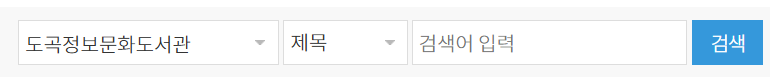

- 중간에 있는 셀렉트박스가 도곡정보문화도서관으로 바뀜

In [3]:
# -----------------------
# 셀렉트박스 옵션 선택 - 텍스트로 선택
# -----------------------
select_box.select_by_visible_text('개포하늘꿈도서관')  # 화면에 보이는 이름 기준 선택
time.sleep(1)


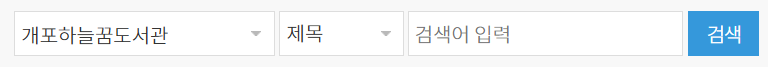

- 중간에 있는 셀렉트박스가 개포하늘꿈도서관으로 바뀜

In [4]:
# -----------------------
# 셀렉트박스 옵션 선택 - 인덱스로 선택
# -----------------------
select_box.select_by_index(1)  # 두 번째 항목 선택
time.sleep(1)

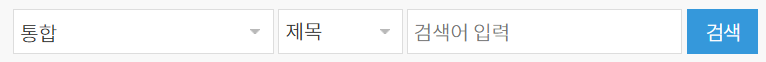

- 중간에 있는 셀렉트박스가 두번째 항목인 통합으로 바뀜

In [5]:
# --------------------------------------
# 브라우저 닫기
# --------------------------------------
driver.quit()